In [2]:
from langchain_openai import ChatOpenAI
from langchain.messages import HumanMessage,SystemMessage
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.document_loaders import DirectoryLoader,PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma, FAISS
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langgraph.graph import StateGraph,START, END,MessagesState
from typing import TypedDict,Annotated,Literal
import os 
import sys
sys.path.insert(1, r'D:\Notebooks\LLM\env')
from enviorment import load_env
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_core.tools import tool
#from pydirectoryloader import rag_function
import os 
load_env()
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.utilities import GoogleSerperAPIWrapper,WikipediaAPIWrapper
import logging
from langchain.agents.middleware import before_model, after_model
from langchain.agents.middleware import SummarizationMiddleware
#from langchain.middleware.summarization import SummarizationMiddleware
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
#from langchain_anthropic.middleware import anthropicPromptCachingMiddleware
from langchain.agents.middleware import TodoListMiddleware
from langgraph.checkpoint.memory import InMemorySaver

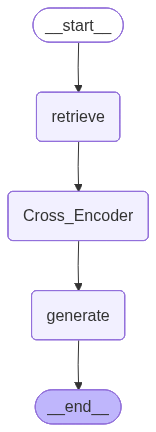

In [3]:
from typing import List, TypedDict, Any
from langgraph.graph import StateGraph, END

from langchain_core.documents import Document
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader

from pydantic import BaseModel, Field
from sentence_transformers import CrossEncoder


# -----------------------------
# 1. Setup (same as your code)
# -----------------------------
path = "Understanding_Climate_Change.pdf"
docs = PyPDFLoader(path).load()

splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings)




# -----------------------------
# 2. State Definition
# -----------------------------
class RAGState(TypedDict):
    query: str
    retrieved_docs: List[Document]
    reranked_docs: List[Document]
    answer: str


# -----------------------------
# 3. Nodes
# -----------------------------

# 🔹 Retrieve Node
def retrieve_node(state: RAGState):
    query = state["query"]
    docs = vector_store.similarity_search(query, k=10)
    return {"retrieved_docs": docs}


# 🔹 Cross-Encoder Rerank Node
def rerank_node(state: RAGState):
    query = state["query"]
    docs = state["retrieved_docs"]

    pairs = [[query, doc.page_content] for doc in docs]
    cross_encoder = CrossEncoder("cross-encoder/ms-marco-TinyBERT-L-2-v2")
    scores = cross_encoder.predict(pairs)

    scored_docs = sorted(zip(docs, scores), key=lambda x: x[1], reverse=True)

    top_docs = [doc for doc, _ in scored_docs[:5]]

    return {"reranked_docs": top_docs}


# 🔹 Answer Generation Node
def generate_node(state: RAGState):
    query = state["query"]
    docs = state["reranked_docs"]

    context = "\n\n".join(doc.page_content for doc in docs)

    prompt = PromptTemplate(
        input_variables=["context", "question"],
        template="""
You are an expert assistant. Answer based only on the context.

Context:
{context}

Question:
{question}

Answer:
"""
    )

    llm = ChatOpenAI(model_name="gpt-4o", temperature=0)

    chain = prompt | llm | StrOutputParser()

    answer = chain.invoke({
        "context": context,
        "question": query
    })

    return {"answer": answer}


# -----------------------------
# 4. Graph Definition
# -----------------------------
graph = StateGraph(RAGState)

graph.add_node("retrieve", retrieve_node)
graph.add_node("Cross_Encoder", rerank_node)
graph.add_node("generate", generate_node)

graph.set_entry_point("retrieve")

graph.add_edge("retrieve", "Cross_Encoder")
graph.add_edge("Cross_Encoder", "generate")
graph.add_edge("generate", END)

app = graph.compile()

app

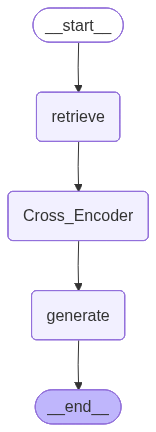

In [6]:
app

In [ ]:

# -----------------------------
# 5. Run
# -----------------------------
query = "What are the impacts of climate change on biodiversity?"

result = app.invoke({"query": query})

print("\nQuestion:", query)
print("\nAnswer:", result["answer"])

print("\nTop Documents:")
for i, doc in enumerate(result["reranked_docs"], 1):
    print(f"\n--- Doc {i} ---")
    print(doc.page_content[:200])